# Sesión 01 (adaptado) — Ciclo de Vida de ML con League of Legends
**Curso:** Ingeniería del Conocimiento (ISO56B)
**Basado en:** Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning (Dataset Heart Disease)
**Dataset nuevo:** League of Legends Diamond Ranked Games (10 min)

---

## Objetivo
Replicar el ciclo de vida completo de un proyecto de Machine Learning (recolección, exploración,
preparación, entrenamiento, evaluación y despliegue conceptual) usando un dataset distinto:
partidas de League of Legends en rango Diamante, con el objetivo de predecir si el
**equipo azul gana la partida** a partir de las estadísticas de los primeros 10 minutos de juego.


## 1. Configuración del entorno
Importamos las mismas librerías que en la Sesión 01. En Google Colab la mayoría ya están disponibles.

In [2]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')


Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos

Dataset: **League of Legends Diamond Ranked Games (10 min)**
Fuente: Kaggle — https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min

Cada fila es una partida de rango Diamante-Maestro. Las columnas describen el estado de la
partida a los **10 minutos** de juego (kills, oro, experiencia, torres, dragones, wards, etc.)
para ambos equipos.

| Variable (ejemplos) | Descripción |
|---|---|
| `blueWins` | **Target**: 1 = ganó el equipo azul, 0 = ganó el equipo rojo |
| `blueKills` / `redKills` | Asesinatos de cada equipo a los 10 min |
| `blueDeaths` / `redDeaths` | Muertes de cada equipo |
| `blueTotalGold` / `redTotalGold` | Oro total acumulado |
| `blueGoldDiff` | Diferencia de oro (azul - rojo) |
| `blueExperienceDiff` | Diferencia de experiencia (azul - rojo) |
| `blueDragons` / `redDragons` | Dragones asesinados |
| `blueTowersDestroyed` / `redTowersDestroyed` | Torres destruidas |
| `blueWardsPlaced` / `redWardsPlaced` | Wards (visión) colocados |

**Antes de ejecutar esta celda:** sube el archivo `high_diamond_ranked_10min.csv`
(descargado de Kaggle) a la sesión de Colab (ícono de carpeta → *Subir archivo*),
o descomenta el bloque de `files.upload()`.

In [3]:
# 2.1 Carga del dataset
# Si estás en Colab y aún no subiste el archivo, descomenta estas líneas:
# from google.colab import files
# uploaded = files.upload()

CSV_PATH = 'high_diamond_ranked_10min.csv'

try:
    df = pd.read_csv(CSV_PATH)
    print(f'Dataset cargado — {df.shape[0]} registros, {df.shape[1]} columnas')
except FileNotFoundError:
    print(f'No se encontró {CSV_PATH}. Sube el archivo a la sesión de Colab e inténtalo de nuevo.')
    raise

df.head()


Dataset cargado — 9879 registros, 40 columnas


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


---
## 3. Etapa 2 — Exploración y preparación de datos

In [4]:
# 3.1  Información general del dataset
df.info()
df.describe().round(2)


<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.0,9879.00,9879.00,9879.0,9879.00,9879.00,9879.00,9879.00,9879.00,...,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00
mean,4.500084e+09,0.5,22.29,2.82,0.5,6.18,6.14,6.65,0.55,0.36,...,0.04,16489.04,6.93,17961.73,217.35,51.31,-14.41,33.62,21.73,1648.90
std,2.757328e+07,0.5,18.02,2.17,0.5,3.01,2.93,4.06,0.63,0.48,...,0.22,1490.89,0.31,1198.58,21.91,10.03,2453.35,1920.37,2.19,149.09
min,4.295358e+09,0.0,5.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,11212.00,4.80,10465.00,107.00,4.00,-11467.00,-8348.00,10.70,1121.20
25%,4.483301e+09,0.0,14.00,1.00,0.0,4.00,4.00,4.00,0.00,0.00,...,0.00,15427.50,6.80,17209.50,203.00,44.00,-1596.00,-1212.00,20.30,1542.75
50%,4.510920e+09,0.0,16.00,3.00,1.0,6.00,6.00,6.00,0.00,0.00,...,0.00,16378.00,7.00,17974.00,218.00,51.00,-14.00,28.00,21.80,1637.80
75%,4.521733e+09,1.0,20.00,4.00,1.0,8.00,8.00,9.00,1.00,1.00,...,0.00,17418.50,7.20,18764.50,233.00,57.00,1585.50,1290.50,23.30,1741.85
max,4.527991e+09,1.0,250.00,27.00,1.0,22.00,22.00,29.00,2.00,1.00,...,2.00,22732.00,8.20,22269.00,289.00,92.00,10830.00,9333.00,28.90,2273.20


In [5]:
# 3.2  Verificación de valores nulos y duplicados
print(df.isnull().sum())
print(f'Registros duplicados: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)


gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

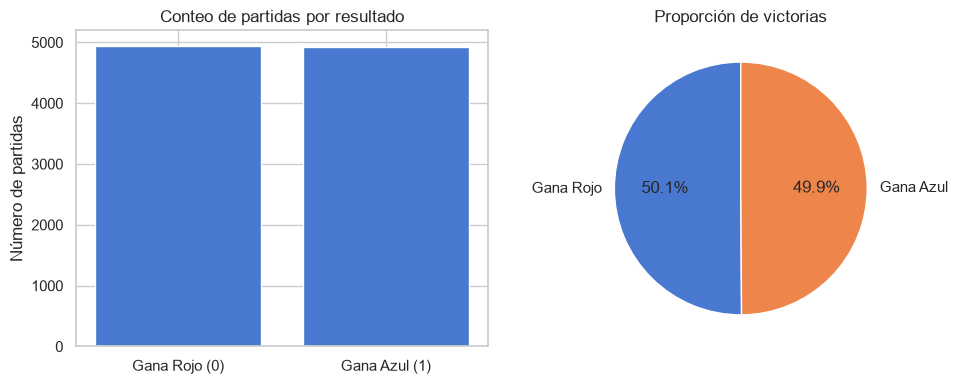

In [6]:
# 3.3  Distribución de la variable objetivo (blueWins)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo = df['blueWins'].value_counts()
axes[0].bar(['Gana Rojo (0)', 'Gana Azul (1)'], conteo.reindex([0, 1]))
axes[0].set_title('Conteo de partidas por resultado')
axes[0].set_ylabel('Número de partidas')

axes[1].pie(conteo.reindex([0, 1]), labels=['Gana Rojo', 'Gana Azul'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de victorias')

plt.tight_layout()
plt.show()


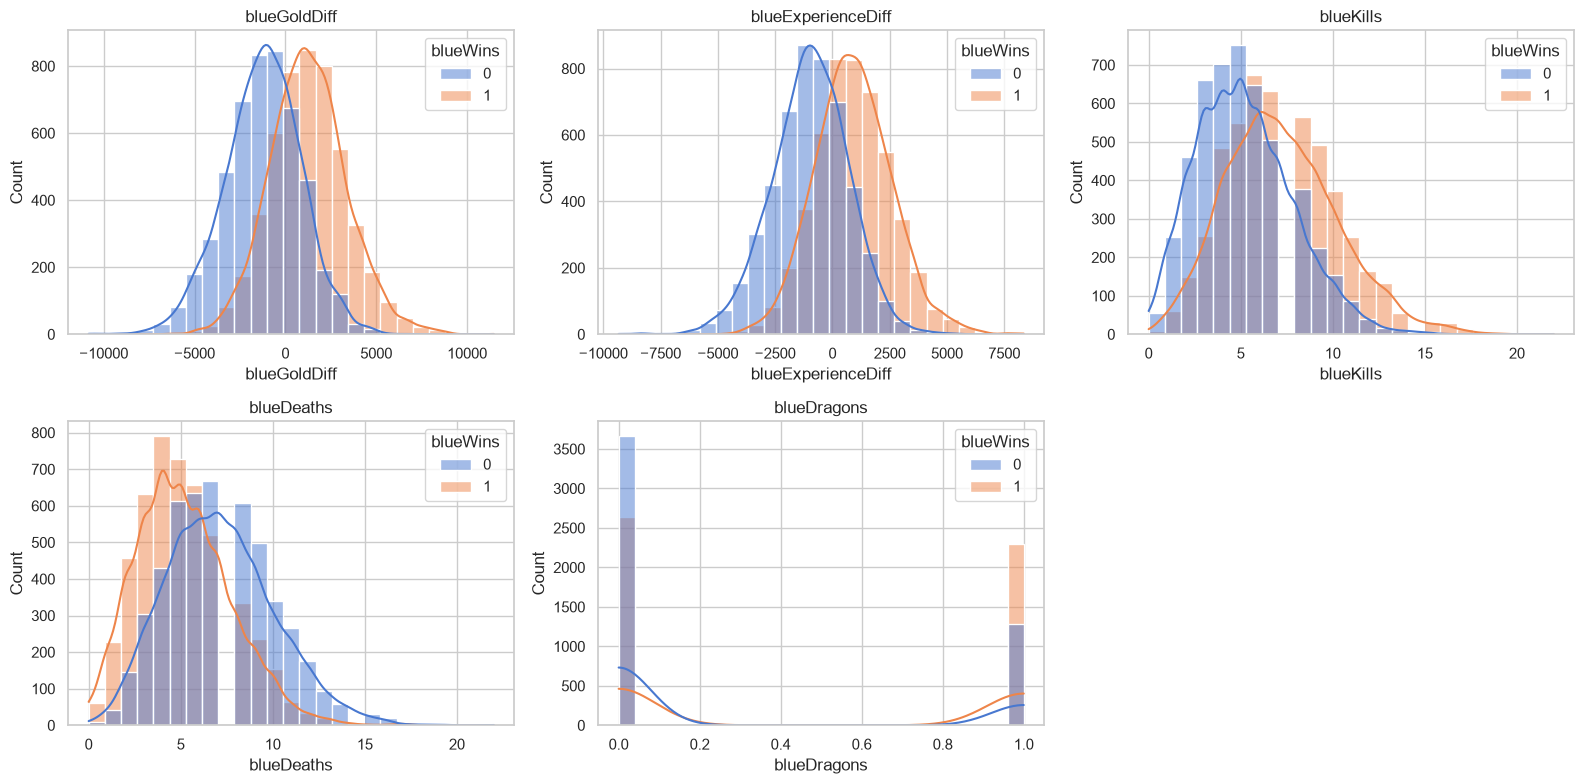

In [7]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['blueGoldDiff', 'blueExperienceDiff', 'blueKills', 'blueDeaths', 'blueDragons']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='blueWins', kde=True, ax=axes[i], bins=25)
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


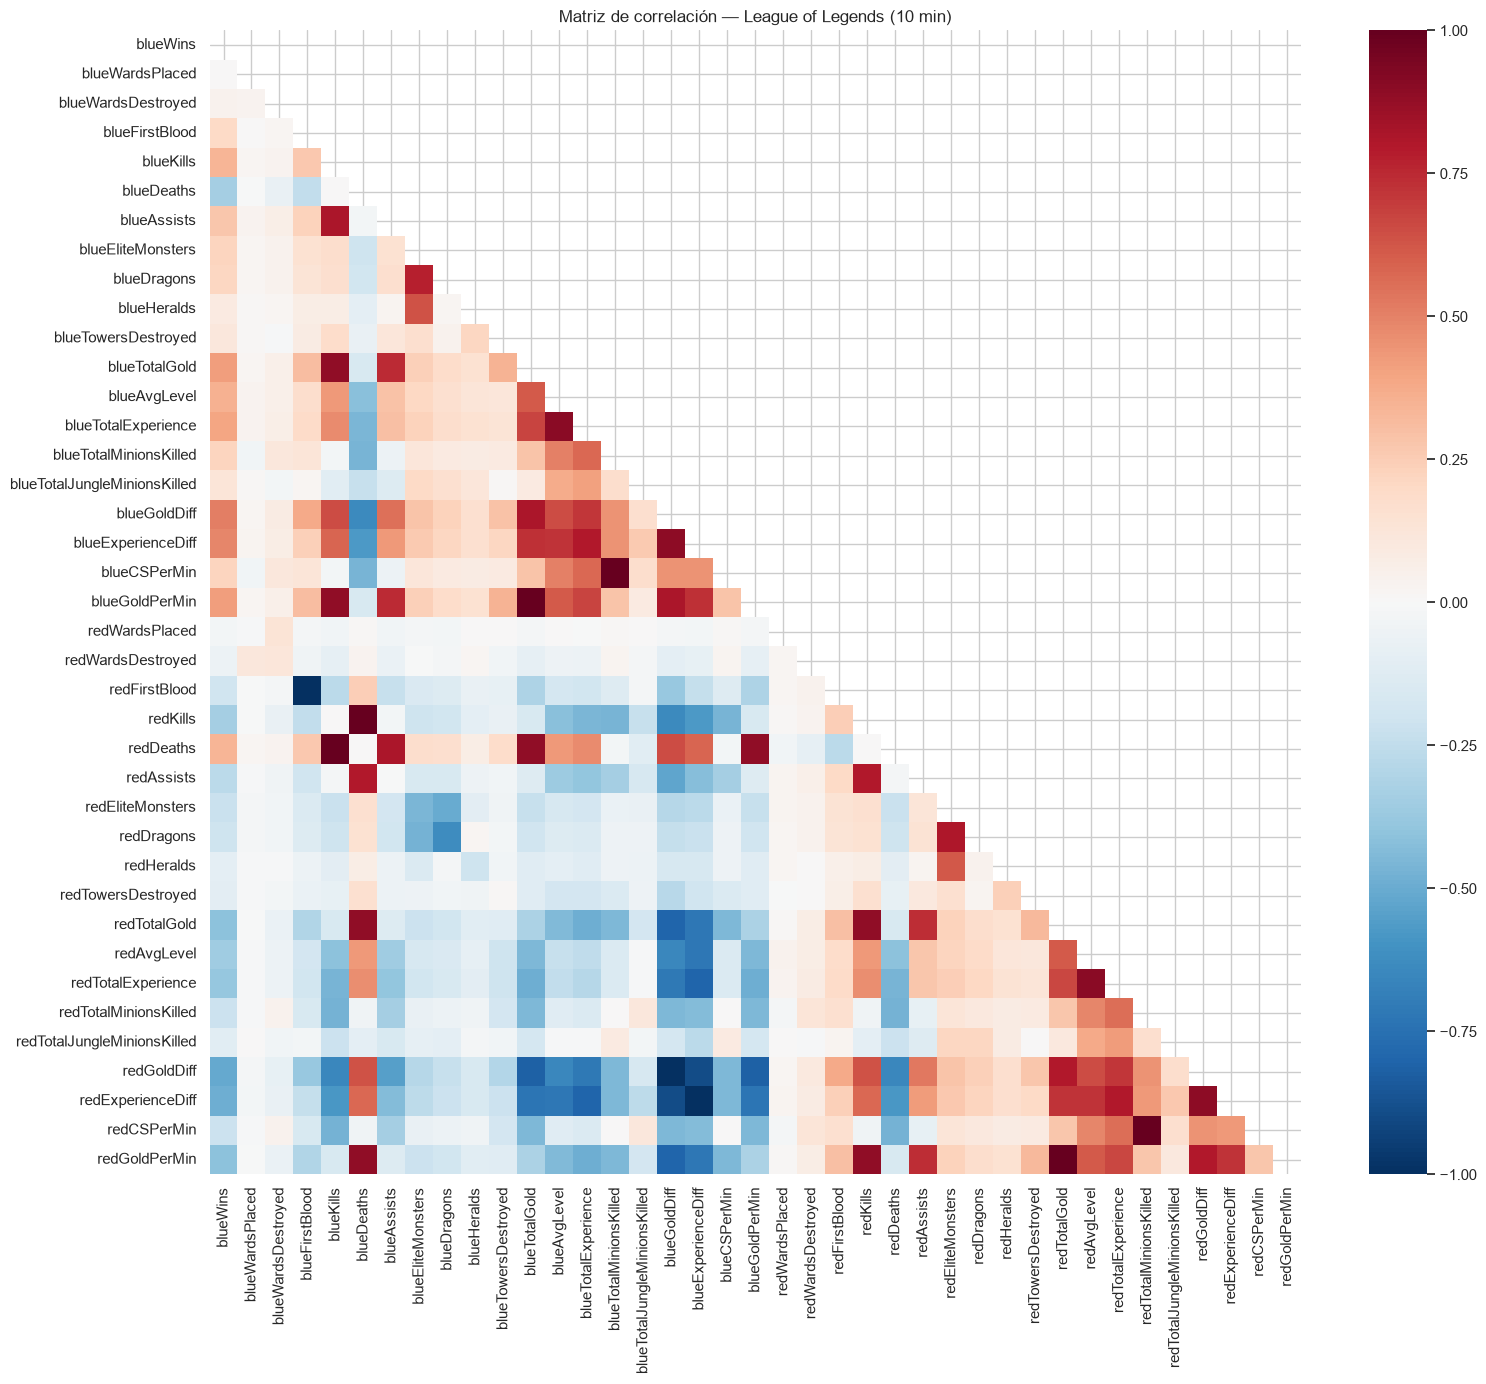

blueWins                        1.000000
blueGoldDiff                    0.511119
blueExperienceDiff              0.489558
blueTotalGold                   0.417213
blueGoldPerMin                  0.417213
blueTotalExperience             0.396141
blueAvgLevel                    0.357820
redDeaths                       0.337358
blueKills                       0.337358
blueAssists                     0.276685
blueCSPerMin                    0.224909
blueTotalMinionsKilled          0.224909
blueEliteMonsters               0.221944
blueDragons                     0.213768
blueFirstBlood                  0.201769
blueTotalJungleMinionsKilled    0.131445
blueTowersDestroyed             0.115566
blueHeralds                     0.092385
blueWardsDestroyed              0.044247
blueWardsPlaced                 0.000087
redWardsPlaced                 -0.023671
redWardsDestroyed              -0.055400
redHeralds                     -0.097172
redTowersDestroyed             -0.103696
redTotalJungleMi

In [8]:
# 3.5  Matriz de correlación
corr = df.drop(columns=['gameId']).corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlación — League of Legends (10 min)')
plt.tight_layout()
plt.show()

# Variables más correlacionadas con el target
print(corr['blueWins'].sort_values(ascending=False))


---
## 4. Etapa 3 — Preparación de datos para el modelado

In [9]:
# 4.1  Separación de features y target
# 'gameId' es solo un identificador de partida, no aporta información predictiva
X = df.drop(columns=['gameId', 'blueWins'])
y = df['blueWins']

feature_names = X.columns.tolist()

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')


Features: (9879, 38)
Target:   (9879,)


In [10]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} partidas | Test: {X_test.shape[0]} partidas')
print(f'Proporción de victorias azules — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')


Train: 7903 partidas | Test: 1976 partidas
Proporción de victorias azules — train: 0.499 | test: 0.499


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos los mismos tres modelos base mediante **pipelines** de Scikit-learn.

In [11]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')


LogisticRegression         Accuracy CV: 0.7316 ± 0.0063
DecisionTree               Accuracy CV: 0.7196 ± 0.0105
RandomForest               Accuracy CV: 0.7299 ± 0.0071


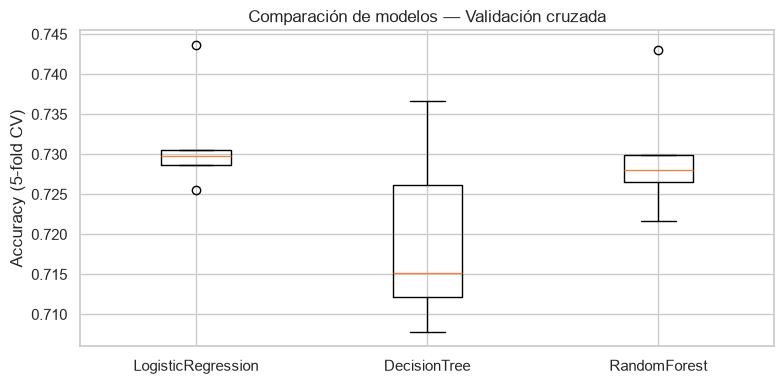

In [12]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()


---
## 6. Etapa 5 — Evaluación del mejor modelo

In [13]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Gana Rojo', 'Gana Azul']))


Mejor modelo: LogisticRegression
Accuracy en test: 0.7161

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Gana Rojo       0.72      0.71      0.71       990
   Gana Azul       0.71      0.72      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



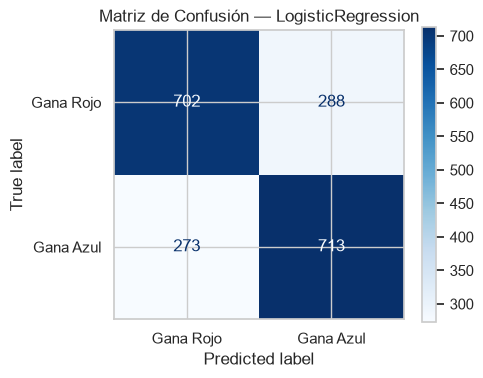

In [14]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Gana Rojo', 'Gana Azul'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()


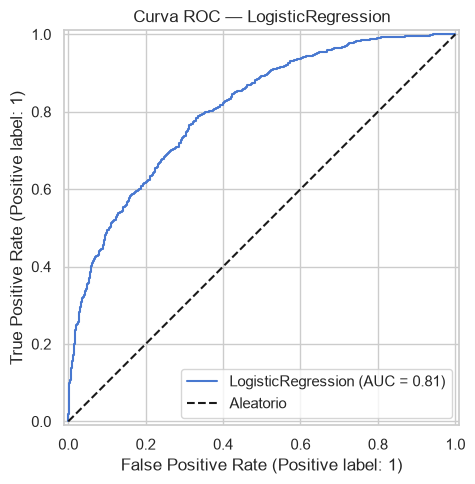

In [15]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()


---
## Ejercicio 1 — Experimentación con hiperparámetros

En este ejercicio se utiliza GridSearchCV para buscar la mejor combinación de hiperparámetros del modelo RandomForestClassifier.

Se comparará el accuracy del modelo original con el accuracy obtenido después de la optimización.

In [17]:
# ============================================================
# EJERCICIO 1 - EXPERIMENTACION CON HIPERPARAMETROS
# ============================================================

# 1. MODELO RANDOM FOREST ORIGINAL
rf_original = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42
    ))
])

rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)
accuracy_original = rf_original.score(X_test, y_test)

# Medimos tambien el baseline con la misma validacion cruzada del tuning
cv_original = cross_val_score(
    rf_original, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1
)

print('===== RANDOM FOREST ORIGINAL =====')
print(f'Accuracy en test antes del tuning: {accuracy_original:.4f}')
print(f'Accuracy CV antes del tuning:      {cv_original.mean():.4f}')


# 2. HIPERPARAMETROS A PROBAR
# Se incluyen controles de complejidad y seleccion de variables para que
# el modelo pueda cambiar de forma mas apreciable.
param_grid = {
    'clf__n_estimators': [50, 100, 200, 400],
    'clf__max_depth': [2, 5, 7, 10, None],
    'clf__min_samples_leaf': [1, 3, 8],
    'clf__max_features': ['sqrt', None]
}


# 3. CONFIGURAMOS GRIDSEARCHCV
grid_search = GridSearchCV(
    estimator=rf_original,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# 4. EJECUTAMOS LA BUSQUEDA
grid_search.fit(X_train, y_train)


# 5. MOSTRAMOS LOS MEJORES PARAMETROS
print('\n===== RESULTADOS DEL GRIDSEARCHCV =====')
print('Mejores hiperparametros:')
print(grid_search.best_params_)
print(f'Mejor accuracy promedio en validacion cruzada: {grid_search.best_score_:.4f}')
print(f'Mejora en CV: {grid_search.best_score_ - cv_original.mean():+.4f}')


# 6. EVALUAMOS EL MODELO OPTIMIZADO EN TEST
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
accuracy_tuned = best_rf.score(X_test, y_test)


# 7. COMPARAMOS LOS RESULTADOS
predicciones_cambiadas = (y_pred_original != y_pred_tuned).sum()
print('\n===== COMPARACION FINAL =====')
print(f'Accuracy en test antes del tuning:  {accuracy_original:.4f}')
print(f'Accuracy en test despues del tuning: {accuracy_tuned:.4f}')
print(f'Diferencia de accuracy en test:       {accuracy_tuned - accuracy_original:+.4f}')
print(f'Predicciones que cambiaron:            {predicciones_cambiadas}')

if predicciones_cambiadas == 0:
    print('Nota: ambos modelos generaron exactamente las mismas predicciones en el test.')
else:
    print('Nota: los modelos generaron predicciones diferentes; por eso puede cambiar el accuracy.')

===== RANDOM FOREST ORIGINAL =====
Accuracy en test antes del tuning: 0.7212
Accuracy CV antes del tuning:      0.7299
Fitting 5 folds for each of 120 candidates, totalling 600 fits

===== RESULTADOS DEL GRIDSEARCHCV =====
Mejores hiperparametros:
{'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 8, 'clf__n_estimators': 400}
Mejor accuracy promedio en validacion cruzada: 0.7324
Mejora en CV: +0.0025

===== COMPARACION FINAL =====
Accuracy en test antes del tuning:  0.7212
Accuracy en test despues del tuning: 0.7212
Diferencia de accuracy en test:       +0.0000
Predicciones que cambiaron:            24
Nota: los modelos generaron predicciones diferentes; por eso puede cambiar el accuracy.


---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [15]:
# 7.1  Guardar el modelo
MODEL_PATH = 'lol_win_prediction_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')


Modelo guardado en: lol_win_prediction_model.joblib


In [16]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')


Verificación OK: el modelo cargado reproduce las predicciones.


In [17]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_blue_win(match_stats: dict) -> dict:
    """
    Recibe un diccionario con las estadísticas de una partida a los 10 minutos
    y retorna la predicción (gana azul / gana rojo) y la probabilidad.
    'match_stats' debe tener las mismas claves que 'feature_names'.
    """
    model = joblib.load(MODEL_PATH)

    try:
        ordered_values = [match_stats[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f'Falta la estadística: {e}. Revisa feature_names para la lista completa.')

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    prediction_label = 'Gana equipo Azul' if pred == 1 else 'Gana equipo Rojo'

    return {
        'prediccion': prediction_label,
        'probabilidad_gana_azul': round(float(proba[1]), 4),
        'probabilidad_gana_rojo': round(float(proba[0]), 4)
    }

# Ejemplo de uso: partida donde el equipo azul va ganando en oro y kills a los 10 min
partida_ejemplo = X_test.iloc[0].to_dict()

resultado = predict_blue_win(partida_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')

print(f'\n(Resultado real de esta partida: {"Gana Azul" if y_test.iloc[0] == 1 else "Gana Rojo"})')



--- Resultado de inferencia ---
  prediccion: Gana equipo Rojo
  probabilidad_gana_azul: 0.3845
  probabilidad_gana_rojo: 0.6155

(Resultado real de esta partida: Gana Rojo)


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset LoL Diamond Ranked (Kaggle) | `pandas` |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |


---
## 9. Ejercicios propuestos (adaptados)

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del
`RandomForestClassifier` sobre este dataset. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Importancia de variables
Usando `best_pipeline.named_steps['clf'].feature_importances_` (si el mejor modelo es un árbol
o RandomForest), identifique las 5 variables más importantes para predecir la victoria.
¿Tiene sentido desde la lógica del juego (oro, experiencia, dragones)?

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de
las métricas y parámetros de cada modelo entrenado en este notebook.

---
*Notebook adaptado — Ciclo de Vida de ML aplicado a League of Legends*